# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/irssaa29/Machine-learning_01/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which content pages should be prioritized for review, and can a simple, explainable model meaningfully outperform a transparent hand-written rule at identifying them?

**Lane: Refresh / Content Opportunity Scoring**

**Decision this supports:** Which pages a content reviewer should look at first, given limited review time (Week 1).

**Action taken on the output:** A reviewer opens the top-ranked pages and updates, expands, or investigates them, guided by a reason code explaining why each page was flagged.

**Cost of a wrong call:** Flagging a healthy page wastes limited reviewer time; missing a genuinely declining page lets it lose visibility unnoticed, a real cost since decline compounds the longer it goes unaddressed (Week 1).

**Unit of analysis:** One content item (content_hash_id), with features built from the first half of a month and an outcome measured in the second half of the same month.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Data source:** FlyRank ML Internship warehouse release (Hugging Face), table fact_content_daily_performance, month partition 2026-03.

**Date window:** March 1–31, 2026, split into two halves — March 1–15 ("before," feature window) and March 16–31 ("after," outcome window).

**Population:** All pages with valid Search Console position data (h1_avg_position > 0), excluding pages with no recorded activity at all in either window. Within this population, pages are further split into two tiers: those with any first-half clicks (h1_ctr > 0, model-eligible) and those with zero first-half clicks despite ranking (h1_ctr == 0, structurally excluded from the decline model — see Methodology).

**Excluded fields:** All ai_* referrer columns (sparse, mostly missing in this slice) and all ga4_*/sessions_* columns (only 21.7% coverage across both GSC and GA4 in this slice — dropped to avoid treating missing data as zero engagement) (Week 3).

**Public-safety note:** No client names, domains, or private queries appear anywhere in this analysis — all identifiers are pseudonymized hashes provided by the dataset itself.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label definition:** A page is labeled is_declining = 1 if its total clicks in the second half of March (Mar 16–31) are lower than its total clicks in the first half (Mar 1–15). This is an observed, within-month comparison, not a proxy rule imposed from outside the data (Week 3).

**Features (5, all from the first half only, so all are knowable before the outcome window exists):** h1_impressions, h1_avg_position, h1_clicks, h1_ctr, h1_active_days (Week 3/5).

**Baseline:** A transparent, hand-written rule — a page scores high if it ranks well (real position data) but underperforms the CTR expected for its position tier, weighted by impression volume, with a minimum volume floor to exclude negligible-traffic pages (Week 4). Reason code: position_ctr_gap.

**Two rounds of signal-checking before building the baseline (Week 4):**

**CTR vs. position (flag-linked to CTR-fix logic):** CONFIRMED — CTR decreases monotonically as position worsens among pages with real position data.

**Volume vs. decline rate (flag-linked to quick-win logic):** OPPOSITE of hypothesis — volume is strongly, not independently, related to decline rate, partly because a page with zero first-half clicks cannot mathematically decline under this label. This finding directly shaped the model population split described below.

**Model:** A depth-3 Decision Tree, chosen for readability over marginal accuracy gains, evaluated by its ranking probability at Precision@K rather than a plain classification (Week 5).

**Validation design:** Client-grouped 70/30 split (GroupShuffleSplit on client_hash_id) — no client's pages appear in both train and test, avoiding client-specific memorization (Week 5/6). A random-split comparison was also run; the gap between the two informed how much confidence to place in either single split (Week 6).

**Leakage checks performed (Week 3, 5, 6):**

Deliberately added a label-derived feature (clicks_change = h2_clicks − h1_clicks) and confirmed the test harness correctly detects it — Precision@50 jumped from 0.80 to 1.00, confirming the harness works and that none of the five real features are label-derived.

Investigated an initial suspiciously high feature importance (h1_ctr at 99.9%) and found it was a structural artifact: pages with h1_ctr == 0 always have h1_clicks == 0, and can never mathematically decline under this label. The model population was corrected to restrict to h1_ctr > 0 pages, after which importance spread across four real signals.



## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

| Metric | Baseline (rule) | Tree (unrestricted) | Tree (restricted, h1_ctr > 0) |
|---|---|---|---|
| Base rate | — | 0.233 | 0.583 |
| Precision@20 | 0.35 | 0.70 | 0.90 |
| Precision@50 | 0.42 | 0.80 | 0.84 |

**Honest reading:** the unrestricted tree's strong-looking numbers were driven almost entirely by the structural artifact described above, not genuine skill. After correcting the population, the restricted tree still clearly outperforms the baseline (Precision@20: 0.90 vs. base rate 0.583 vs. baseline rule 0.35), and its feature importance is spread across four interpretable signals (h1_ctr 44%, h1_avg_position 31%, h1_active_days 14%, h1_impressions 11%), not dominated by one artifact (Week 5/6).

**Random vs. grouped split (Week 6):** Precision@20 was 0.55 (random) vs. 0.70 (grouped, unrestricted population) — an unusual direction (grouped scored higher), attributable to high variance from a small number of unique clients (44 total, 14rather than the more typical memorization pattern. This is disclosed as a genuine limitation of this validation design, not smoothed over.

**Error analysis:** the model's false negatives (Week 5) were pages with strong position, consistent visibility, and real traffic that still declined — cases the first-half snapshot features couldn't foresee, since they capture a page's state, not the forces acting on it (e.g., a competitor overtaking it). in the held-out test)

## 5. Limitations

*What this work cannot claim.*

**What this work can say:** Based on this dataset, certain observable signals — position, CTR relative to position, impression volume, visibility consistency — are associated with whether a page's traffic held up or declined over a two-week window. A simple, explainable model ranks pages by this pattern more effectively than a hand-written rule, when properly restricted to a population where decline is even possible. This is directional, decision-support evidence: a ranked starting list for a human reviewer, not a verdict.

**What this work cannot say:**

No causal claim. I cannot say that refreshing a flagged page will recover its traffic — that requires a controlled experiment (e.g., refresh some pages, hold out similar ones, compare outcomes), which this observational dataset does not provide.

No claim about Google's algorithm. This work observes search performance outcomes; it does not reverse-engineer or predict how Google's ranking system itself works.

Single-month snapshot. All results come from one month (March 2026). A one-month analysis cannot distinguish a durable pattern from a seasonal blip —repeating this on additional months would strengthen confidence considerably (Week 4/7).

Small client count limits split stability. With only 44 unique clients, a single grouped train/test split carries real sampling variance, as shown by the random-vs-grouped comparison (Week 6). Results should be treated as one data point, not a stable, final number.

Two-thirds of the full page population is unvalidated. 65.6% of valid-position pages have zero first-half clicks and are structurally excluded from the decline model; they're flagged by a separate, unvalidated rule (zero_click_despite_ranking) with no measured precision behind it (Week 7).

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**The validated model and the population-aware rule together produce a two-tier action playbook (Week 7):**

| Tier | Population | Reason code | Action | Confidence |
|---|---|---|---|---|
| A | Pages with real clicks (h1_ctr > 0) | position_ctr_gap | Review for CTR fix | Model-validated (Precision@20 = 0.90) |
| B | Pages with zero clicks despite ranking (h1_ctr == 0) | zero_click_despite_ranking | Investigate indexing/relevance | Rule-flagged, unvalidated |

**Human review required for every flagged page** — confirm content relevance and query-intent match, check position stability across the month (not just the average), and rule out indexing/technical issues before assuming a content problem (Week 7).

**Never automate:** publishing content changes, deleting/de-indexing pages, or acting on Tier B rows without manual investigation — this tier has no validated precision behind it (Week 7).

**Monitoring triggers (re-validate or retrain if any of these occur):** Precision@20 drops meaningfully below 0.90 on a fresh month; the declining base rate shifts substantially from 0.583; one feature's importance spikes above ~70% again (signaling a new structural artifact); Tier B's share grows well beyond 65.6% (possible portfolio-wide technical issue); the client mix changes meaningfully from the validated 44; or more than one additional month hasn't yet been checked against these thresholds (Week 7).

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

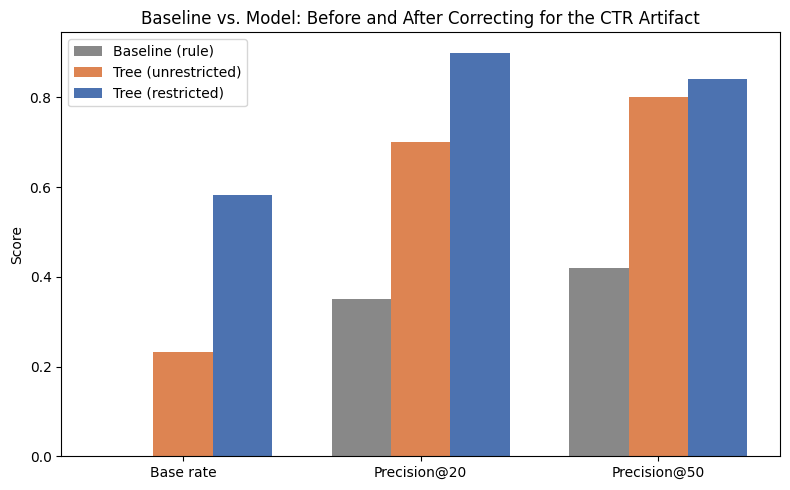

Saved: work/figures/results_comparison.png


In [2]:
import os
import matplotlib.pyplot as plt

# --- Chart 1: Baseline vs Tree comparison ---
metrics_names = ["Base rate", "Precision@20", "Precision@50"]
baseline_vals = [None, 0.35, 0.42]
tree_unrestricted = [0.233, 0.70, 0.80]
tree_restricted = [0.583, 0.90, 0.84]

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(metrics_names))
width = 0.25

ax.bar([i - width for i in x], [0, 0.35, 0.42], width, label="Baseline (rule)", color="#888888")
ax.bar(x, tree_unrestricted, width, label="Tree (unrestricted)", color="#DD8452")
ax.bar([i + width for i in x], tree_restricted, width, label="Tree (restricted)", color="#4C72B0")

ax.set_xticks(list(x))
ax.set_xticklabels(metrics_names)
ax.set_ylabel("Score")
ax.set_title("Baseline vs. Model: Before and After Correcting for the CTR Artifact")
ax.legend()
plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)
plt.savefig("work/figures/results_comparison.png", dpi=150)
plt.show()
print("Saved: work/figures/results_comparison.png")

**5-Minute Demo Outline**
**Question (30s):** Which pages should a content reviewer check first — and can a simple model beat a hand-written rule at finding them?
**Method (1 min):** Built a baseline rule from real FlyRank warehouse data, then trained a readable decision tree, validated on clients the model never saw.
**One chart (1 min):** Show the Baseline vs. Tree comparison chart — walk through how the "unrestricted" result looked great but was a structural artifact, and the "restricted" result is the real, defensible one.
**One honest result (1 min):** Precision@20 of 0.90 against a base rate of 0.583 — real lift, but from one month, one split, on 44 clients — stated with its actual limitations, not oversold.
**One recommendation (1 min):** A two-tier action playbook — model-validated CTR-fix candidates, and a separate, unvalidated but useful "zero-click despite ranking" watchlist — with clear human-review rules and a no-go list for what should never be automated.

**Shareable Cut 1 — Social Post**

"Spent 8 weeks building a content-prioritization model on 79M rows of real search data. The most interesting finding wasn't the model — it was catching my own mistake: my first result looked amazing (90%+ precision) because of a hidden artifact in how I'd defined my label. Fixing it gave a smaller, but real and defensible, result. Full writeup + reproducible code: [link]"

**Shareable Cut 2 — Employer-Facing Summary**

"I built and validated a content-refresh prioritization model on FlyRank's real search-performance warehouse (79M+ rows), using a client-grouped validation design to avoid overstating results. The model achieved a genuine, artifact-corrected Precision@20 of 0.90 against a 0.583 base rate, and I converted it into a two-tier action playbook with explicit human-review rules and defined no-go cases for automation."

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
